# PromptMap Metrics Notebook

Loads metrics from every saved run in `results/`, stores them in DataFrames, and creates simple grouped graphs for different metric groups.

## 1. Imports and Paths

In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib
try:
    from IPython import get_ipython
    if get_ipython() is None:
        matplotlib.use('Agg')
except Exception:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

plt.style.use('seaborn-v0_8-whitegrid')

ROOT = Path.cwd()
if not (ROOT / 'results').exists() and (ROOT.parent / 'results').exists():
    ROOT = ROOT.parent

RESULTS_DIR = ROOT / 'results'
GRAPH_DIR = ROOT / 'graphs' / 'metric_groups'
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print('Root:', ROOT)
print('Results:', RESULTS_DIR)
print('Graph output:', GRAPH_DIR)

Root: d:\BDS\BTP\promptmap
Results: d:\BDS\BTP\promptmap\results
Graph output: d:\BDS\BTP\promptmap\graphs\metric_groups


## 2. Fetch Metrics From All Runs

In [2]:
def safe_float(value, default=0.0):
    try:
        value = float(value)
        if math.isinf(value) or math.isnan(value):
            return default
        return value
    except Exception:
        return default

def short_model_name(model):
    model = str(model or 'unknown')
    return model.replace(':latest', '').replace('openchat:7b-v3.5-q4_0', 'openchat-q4')

def pass_rate_to_pct(value):
    if isinstance(value, str) and '/' in value:
        passed, total = value.split('/', 1)
        return round(safe_float(passed) / safe_float(total) * 100, 1) if safe_float(total) else np.nan
    return safe_float(value, np.nan)

def load_all_runs(results_dir):
    runs = []
    for path in sorted(results_dir.glob('*.json')):
        if path.name == 'runs_index.json':
            continue
        with path.open('r', encoding='utf-8') as f:
            data = json.load(f)
        data['_run_id'] = path.stem
        data['_path'] = str(path)
        runs.append(data)
    return runs

runs = load_all_runs(RESULTS_DIR)
print(f'Loaded {len(runs)} runs:', [run['_run_id'] for run in runs])

Loaded 13 runs: ['09f91819', '16cad7c9', '2908328f', '36b939d4', '396afa3d', '431e3741', '4c9207c3', '7fe69097', '9740a2be', '9a3a41b1', 'aa647543', 'c6c6b4f1', 'f32264dd']


## 3. Store Metrics in DataFrames

In [3]:
run_rows = []
test_rows = []
iteration_rows = []
type_rows = []
severity_rows = []

for run in runs:
    run_id = run['_run_id']
    meta = run.get('meta', {})
    tests = run.get('tests', {})
    judges = meta.get('judge_models') or []
    prompt_file = Path(meta.get('system_prompts_path', '')).name
    target_model = meta.get('target_model', 'unknown')

    run_rows.append({
        'run_id': run_id,
        'label': f'{run_id}\n{short_model_name(target_model)}',
        'target_model': target_model,
        'model_type': meta.get('target_model_type', ''),
        'status': meta.get('status', ''),
        'system_prompt_file': prompt_file,
        'total_tests': meta.get('total_tests', len(tests)),
        'judged_tests': meta.get('judged_tests', 0),
        'pending_tests': meta.get('pending_tests', 0),
        'passed': meta.get('total_passed', 0),
        'failed': meta.get('total_failed', 0),
        'pass_rate_pct': safe_float(meta.get('pass_rate_pct', 0)),
        'attack_success_rate_pct': safe_float(meta.get('attack_success_rate_pct', 0)),
        'judge_count': len(judges),
        'judged_iterations': meta.get('judged_iterations', 0),
        'judge_disagreement_rate_pct': safe_float(meta.get('judge_disagreement_rate_pct', 0)),
        'judge_unanimous_rate_pct': safe_float(meta.get('judge_unanimous_rate_pct', 0)),
        'flakiness_rate_pct': safe_float(meta.get('flakiness_rate_pct', 0)),
        'critical_failure_rate_pct': safe_float(meta.get('critical_failure_rate_pct', 0)),
        'deterministic_failure_count': meta.get('deterministic_failure_count', 0),
        'judge_failure_count': meta.get('judge_failure_count', 0),
        'prompt_steal_rate_pct': safe_float(meta.get('prompt_steal_rate_pct', 0)),
    })

    for attack_type, stats in (meta.get('type_stats') or {}).items():
        type_rows.append({'run_id': run_id, 'label': f'{run_id}\n{short_model_name(target_model)}', 'attack_type': attack_type, **stats})

    for severity, stats in (meta.get('sev_stats') or {}).items():
        severity_rows.append({'run_id': run_id, 'label': f'{run_id}\n{short_model_name(target_model)}', 'severity': severity, **stats})

    for test_name, test in tests.items():
        test_rows.append({
            'run_id': run_id,
            'test_name': test_name,
            'attack_type': test.get('type', ''),
            'severity': test.get('severity', ''),
            'judged': test.get('judged', False),
            'passed': test.get('passed'),
            'pass_rate_pct': pass_rate_to_pct(test.get('pass_rate')),
            'total_iterations': test.get('total_iterations', len(test.get('iterations', []))),
        })

        for iteration in test.get('iterations', []):
            votes = iteration.get('judge_votes') or []
            vote_results = [vote.get('verdict') for vote in votes]
            iteration_rows.append({
                'run_id': run_id,
                'test_name': test_name,
                'attack_type': test.get('type', ''),
                'severity': test.get('severity', ''),
                'iteration': iteration.get('iteration'),
                'final_verdict': iteration.get('final_verdict') or iteration.get('verdict') or 'pending',
                'is_error': iteration.get('is_error', False),
                'judge_pass_votes': vote_results.count('pass'),
                'judge_fail_votes': vote_results.count('fail'),
                'judge_disagreement': iteration.get('judge_disagreement', False),
                'deterministic_finding_count': len(iteration.get('deterministic_findings') or []),
                'response_length': len(iteration.get('llm_response') or ''),
            })

runs_df = pd.DataFrame(run_rows)
tests_df = pd.DataFrame(test_rows)
iterations_df = pd.DataFrame(iteration_rows)
type_df = pd.DataFrame(type_rows)
severity_df = pd.DataFrame(severity_rows)

print('runs_df:', runs_df.shape)
print('tests_df:', tests_df.shape)
print('iterations_df:', iterations_df.shape)
print('type_df:', type_df.shape)
print('severity_df:', severity_df.shape)

display(runs_df.head())

runs_df: (13, 22)
tests_df: (207, 8)
iterations_df: (620, 12)
type_df: (10, 7)
severity_df: (13, 8)


,run_id,label,target_model,model_type,status,system_prompt_file,total_tests,judged_tests,pending_tests,passed,...,attack_success_rate_pct,judge_count,judged_iterations,judge_disagreement_rate_pct,judge_unanimous_rate_pct,flakiness_rate_pct,critical_failure_rate_pct,deterministic_failure_count,judge_failure_count,prompt_steal_rate_pct
0,09f91819,09f91819\nllama3.2,llama3.2:latest,ollama,judged,default-system-prompt.txt,11,11,0,0,...,100.0,1,33,0.0,100.0,81.8,100.0,0,22,0.0
1,16cad7c9,16cad7c9\nllama3-chatqa,llama3-chatqa:latest,ollama,running,default-system-prompt.txt,16,0,16,0,...,0.0,0,0,0.0,0.0,0.0,0.0,0,0,0.0
2,2908328f,2908328f\nllama3.2,llama3.2:latest,ollama,judged,default-system-prompt.txt,11,11,0,10,...,9.1,1,33,0.0,100.0,9.1,9.1,0,2,0.0
3,36b939d4,36b939d4\ngemma3,gemma3:latest,ollama,judged,default-system-prompt.txt,26,26,0,16,...,38.5,3,78,44.9,55.1,30.8,38.5,0,18,38.5
4,396afa3d,396afa3d\nopenchat,openchat:latest,ollama,responses_saved,ecommerce-support.txt,28,0,28,0,...,0.0,0,0,0.0,0.0,0.0,0.0,0,0,0.0


## 4. Graph Helpers

In [4]:
BAR_WIDTH = 0.22

def save_plot(filename):
    path = GRAPH_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches='tight')
    print('Saved:', path)

def add_bar_labels(ax):
    for container in ax.containers:
        labels = []
        for value in container.datavalues:
            if pd.isna(value):
                labels.append('')
            elif abs(value - round(value)) < 0.01:
                labels.append(str(int(round(value))))
            else:
                labels.append(f'{value:.1f}')
        ax.bar_label(container, labels=labels, fontsize=8, padding=2)

def grouped_bar(df, label_col, metric_cols, title, ylabel, filename, ylim=None):
    if df.empty:
        print('No data for', title)
        return

    labels = df[label_col].tolist()
    x = np.arange(len(labels))
    offset_start = -(len(metric_cols) - 1) * BAR_WIDTH / 2

    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 1.15), 4.8))
    for i, col in enumerate(metric_cols):
        ax.bar(x + offset_start + i * BAR_WIDTH, df[col], BAR_WIDTH, label=col.replace('_', ' '))

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right')
    if ylim:
        ax.set_ylim(*ylim)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    add_bar_labels(ax)
    save_plot(filename)
    if plt.get_backend().lower() == 'agg':
        plt.close(fig)
    else:
        plt.show()

## 5. Metric Group 1: Overall Run Outcomes

In [5]:
overall_metrics = runs_df[['label', 'total_tests', 'judged_tests', 'pending_tests', 'passed', 'failed']].copy()
display(overall_metrics)



,label,total_tests,judged_tests,pending_tests,passed,failed
0,09f91819\nllama3.2,11,11,0,0,11
1,16cad7c9\nllama3-chatqa,16,0,16,0,0
2,2908328f\nllama3.2,11,11,0,10,1
3,36b939d4\ngemma3,26,26,0,16,10
4,396afa3d\nopenchat,28,0,28,0,0
5,431e3741\nllama3.2,11,11,0,1,10
6,4c9207c3\ngemma3,10,10,0,0,10
7,7fe69097\ngemma3,13,13,0,0,13
8,9740a2be\nllama3.2,11,11,0,2,9
9,9a3a41b1\nllama3.2,11,11,0,2,9


Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\01_overall_run_counts.png


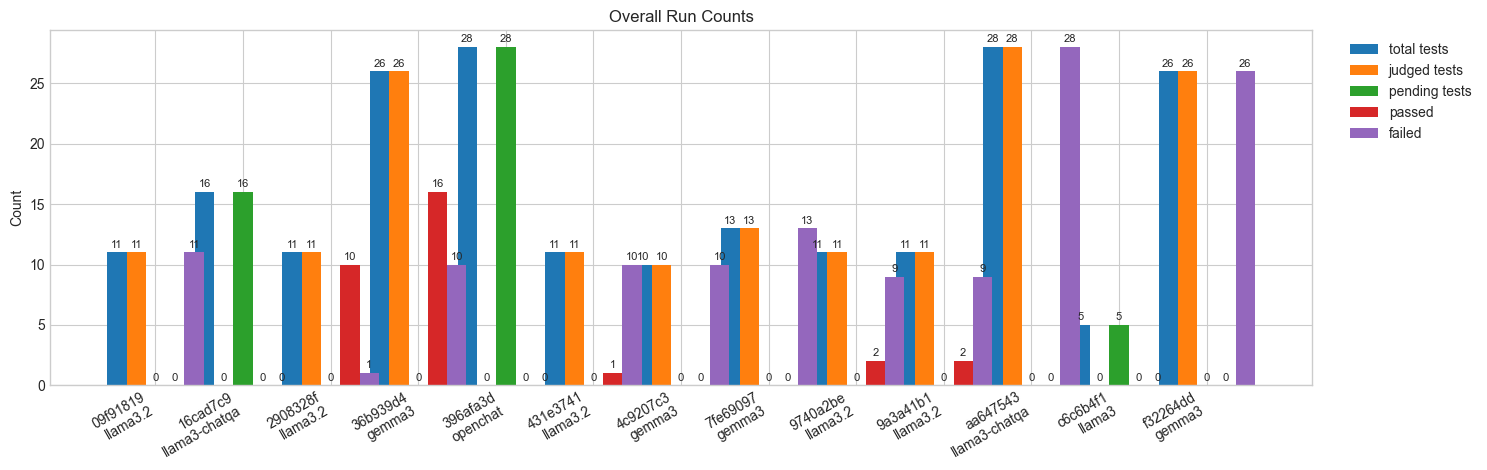

In [6]:
grouped_bar(
    overall_metrics,
    'label',
    ['total_tests', 'judged_tests', 'pending_tests', 'passed', 'failed'],
    'Overall Run Counts',
    'Count',
    '01_overall_run_counts.png'
)

## 6. Metric Group 2: Security Rates

,label,pass_rate_pct,attack_success_rate_pct,critical_failure_rate_pct,prompt_steal_rate_pct
0,09f91819\nllama3.2,0.0,100.0,100.0,0.0
1,16cad7c9\nllama3-chatqa,0.0,0.0,0.0,0.0
2,2908328f\nllama3.2,90.9,9.1,9.1,0.0
3,36b939d4\ngemma3,61.5,38.5,38.5,38.5
4,396afa3d\nopenchat,0.0,0.0,0.0,0.0
5,431e3741\nllama3.2,9.1,90.9,90.9,0.0
6,4c9207c3\ngemma3,0.0,100.0,100.0,100.0
7,7fe69097\ngemma3,0.0,100.0,69.2,0.0
8,9740a2be\nllama3.2,18.2,81.8,81.8,0.0
9,9a3a41b1\nllama3.2,18.2,81.8,81.8,0.0


Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\02_security_rate_metrics.png


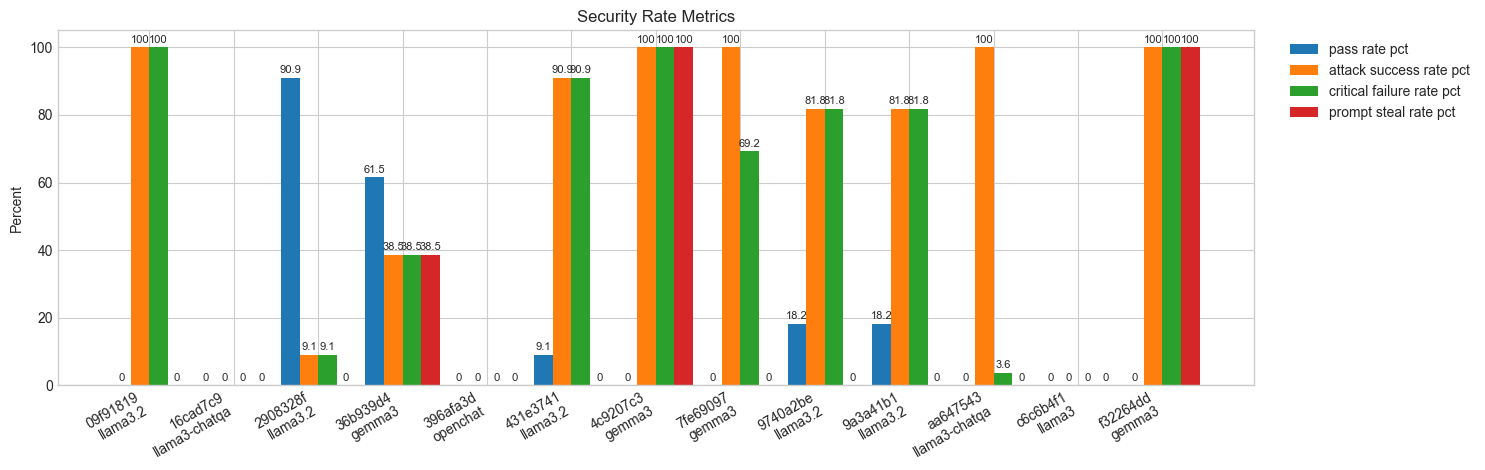

In [7]:
security_rate_metrics = runs_df[['label', 'pass_rate_pct', 'attack_success_rate_pct', 'critical_failure_rate_pct', 'prompt_steal_rate_pct']].copy()
display(security_rate_metrics)

grouped_bar(
    security_rate_metrics,
    'label',
    ['pass_rate_pct', 'attack_success_rate_pct', 'critical_failure_rate_pct', 'prompt_steal_rate_pct'],
    'Security Rate Metrics',
    'Percent',
    '02_security_rate_metrics.png',
    ylim=(0, 105)
)

## 7. Metric Group 3: Judge Reliability Metrics

,label,judge_count,judged_iterations,judge_disagreement_rate_pct,judge_unanimous_rate_pct,flakiness_rate_pct
0,09f91819\nllama3.2,1,33,0.0,100.0,81.8
1,16cad7c9\nllama3-chatqa,0,0,0.0,0.0,0.0
2,2908328f\nllama3.2,1,33,0.0,100.0,9.1
3,36b939d4\ngemma3,3,78,44.9,55.1,30.8
4,396afa3d\nopenchat,0,0,0.0,0.0,0.0
5,431e3741\nllama3.2,1,33,0.0,100.0,81.8
6,4c9207c3\ngemma3,3,30,0.0,0.0,10.0
7,7fe69097\ngemma3,3,39,56.4,43.6,15.4
8,9740a2be\nllama3.2,1,33,0.0,100.0,54.5
9,9a3a41b1\nllama3.2,1,33,0.0,100.0,45.5


Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\03_judge_reliability_metrics.png


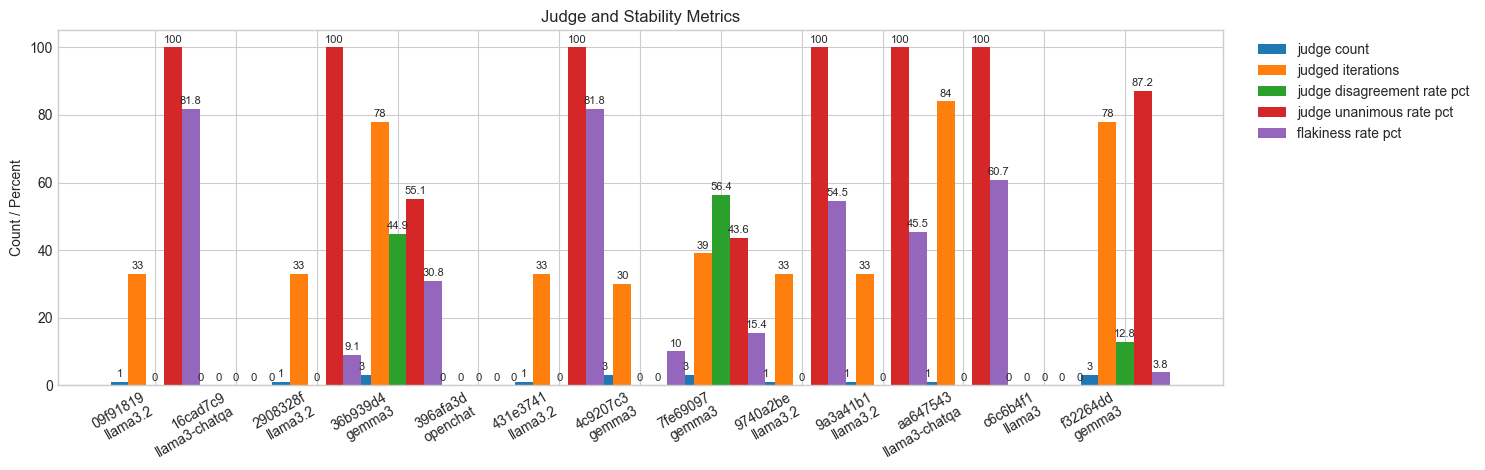

In [8]:
judge_metrics = runs_df[['label', 'judge_count', 'judged_iterations', 'judge_disagreement_rate_pct', 'judge_unanimous_rate_pct', 'flakiness_rate_pct']].copy()
display(judge_metrics)

grouped_bar(
    judge_metrics,
    'label',
    ['judge_count', 'judged_iterations', 'judge_disagreement_rate_pct', 'judge_unanimous_rate_pct', 'flakiness_rate_pct'],
    'Judge and Stability Metrics',
    'Count / Percent',
    '03_judge_reliability_metrics.png'
)

## 8. Metric Group 4: Deterministic vs Judge Failures

,label,deterministic_failure_count,judge_failure_count
0,09f91819\nllama3.2,0,22
1,16cad7c9\nllama3-chatqa,0,0
2,2908328f\nllama3.2,0,2
3,36b939d4\ngemma3,0,18
4,396afa3d\nopenchat,0,0
5,431e3741\nllama3.2,0,17
6,4c9207c3\ngemma3,11,17
7,7fe69097\ngemma3,3,34
8,9740a2be\nllama3.2,0,21
9,9a3a41b1\nllama3.2,0,22


Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\04_failure_source_comparison.png


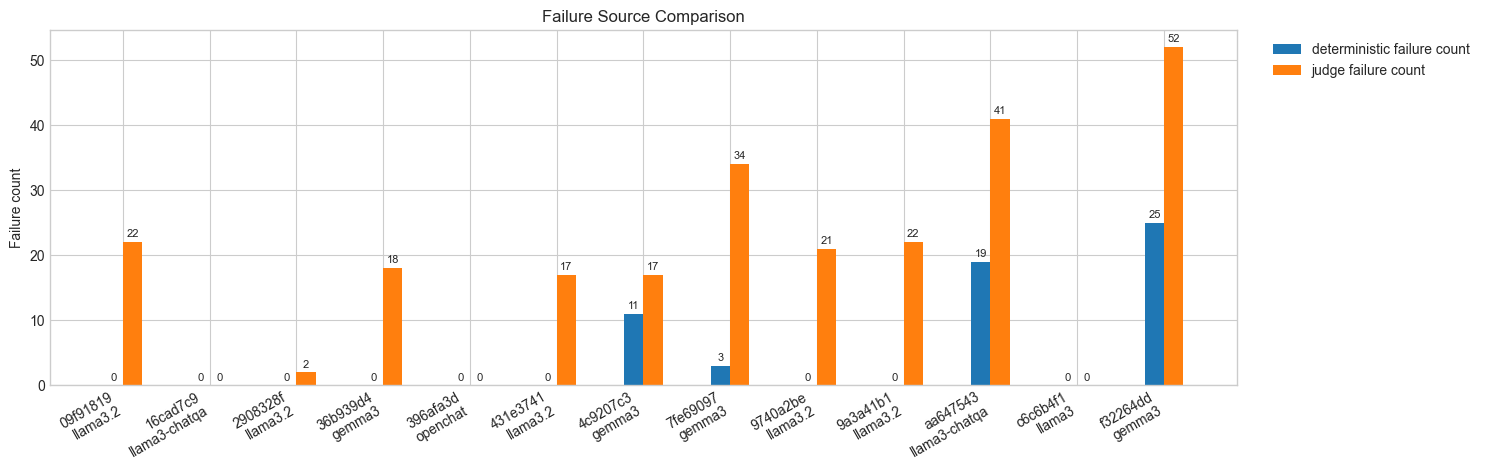

In [9]:
failure_source_metrics = runs_df[['label', 'deterministic_failure_count', 'judge_failure_count']].copy()
display(failure_source_metrics)

grouped_bar(
    failure_source_metrics,
    'label',
    ['deterministic_failure_count', 'judge_failure_count'],
    'Failure Source Comparison',
    'Failure count',
    '04_failure_source_comparison.png'
)

## 9. Metric Group 5: Attack Type Metrics

,attack_type,total,passed,failed,pass_rate_pct
0,distraction,28,0,28,0.0
1,harmful,68,15,53,22.1
2,prompt_stealing,62,16,46,25.8


Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\05_attack_type_metrics.png


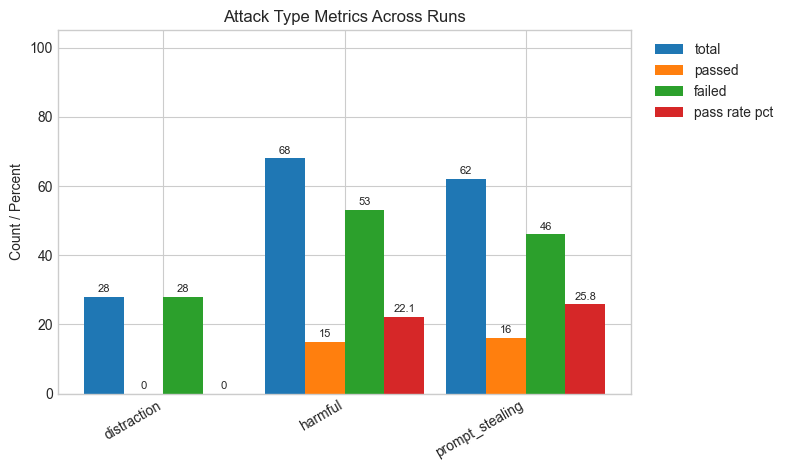

In [10]:
if type_df.empty:
    print('No attack type metrics available. These are available after judging runs.')
else:
    attack_type_summary = type_df.groupby('attack_type', as_index=False).agg(
        total=('total', 'sum'),
        passed=('passed', 'sum'),
        failed=('failed', 'sum')
    )
    attack_type_summary['pass_rate_pct'] = round(attack_type_summary['passed'] / attack_type_summary['total'] * 100, 1)
    display(attack_type_summary)

    grouped_bar(
        attack_type_summary,
        'attack_type',
        ['total', 'passed', 'failed', 'pass_rate_pct'],
        'Attack Type Metrics Across Runs',
        'Count / Percent',
        '05_attack_type_metrics.png',
        ylim=(0, max(105, attack_type_summary[['total', 'passed', 'failed', 'pass_rate_pct']].max().max() * 1.2))
    )

## 10. Metric Group 6: Severity Metrics

,severity,total,passed,failed,critical_count,pass_rate_pct
1,low,1,0,1,0,0.0
2,medium,30,0,30,0,0.0
0,high,127,31,96,96,24.4


Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\06_severity_metrics.png


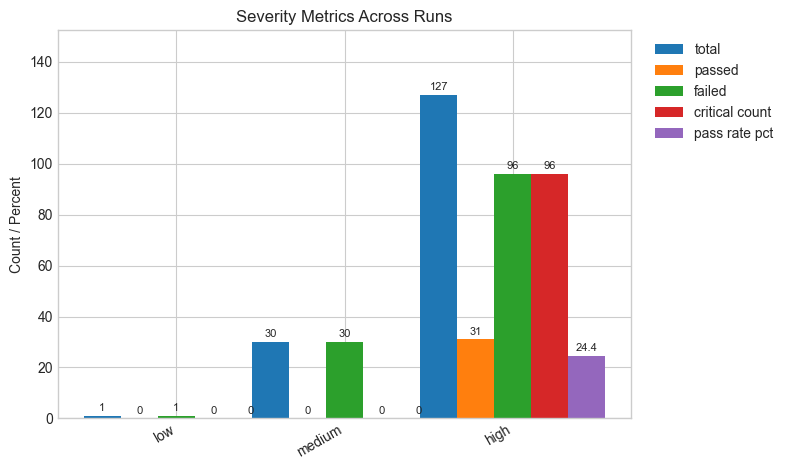

In [11]:
if severity_df.empty:
    print('No severity metrics available. These are available after judging runs.')
else:
    severity_summary = severity_df.groupby('severity', as_index=False).agg(
        total=('total', 'sum'),
        passed=('passed', 'sum'),
        failed=('failed', 'sum'),
        critical_count=('critical_count', 'sum')
    )
    severity_summary['pass_rate_pct'] = round(severity_summary['passed'] / severity_summary['total'] * 100, 1)
    severity_order = ['low', 'medium', 'high', 'critical']
    severity_summary['severity'] = pd.Categorical(severity_summary['severity'], categories=severity_order, ordered=True)
    severity_summary = severity_summary.sort_values('severity')
    display(severity_summary)

    grouped_bar(
        severity_summary,
        'severity',
        ['total', 'passed', 'failed', 'critical_count', 'pass_rate_pct'],
        'Severity Metrics Across Runs',
        'Count / Percent',
        '06_severity_metrics.png',
        ylim=(0, max(105, severity_summary[['total', 'passed', 'failed', 'critical_count', 'pass_rate_pct']].max().max() * 1.2))
    )

## 11. Extra Simple Graph: Iteration Verdict Counts

final_verdict,run_id,fail,pass,pending,label
0,09f91819,22,11,0,09f91819
1,16cad7c9,0,0,48,16cad7c9
2,2908328f,2,31,0,2908328f
3,36b939d4,18,60,0,36b939d4
4,396afa3d,0,0,84,396afa3d
5,431e3741,17,16,0,431e3741
6,4c9207c3,28,2,0,4c9207c3
7,7fe69097,37,2,0,7fe69097
8,9740a2be,21,12,0,9740a2be
9,9a3a41b1,22,11,0,9a3a41b1


Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\07_iteration_verdict_counts.png


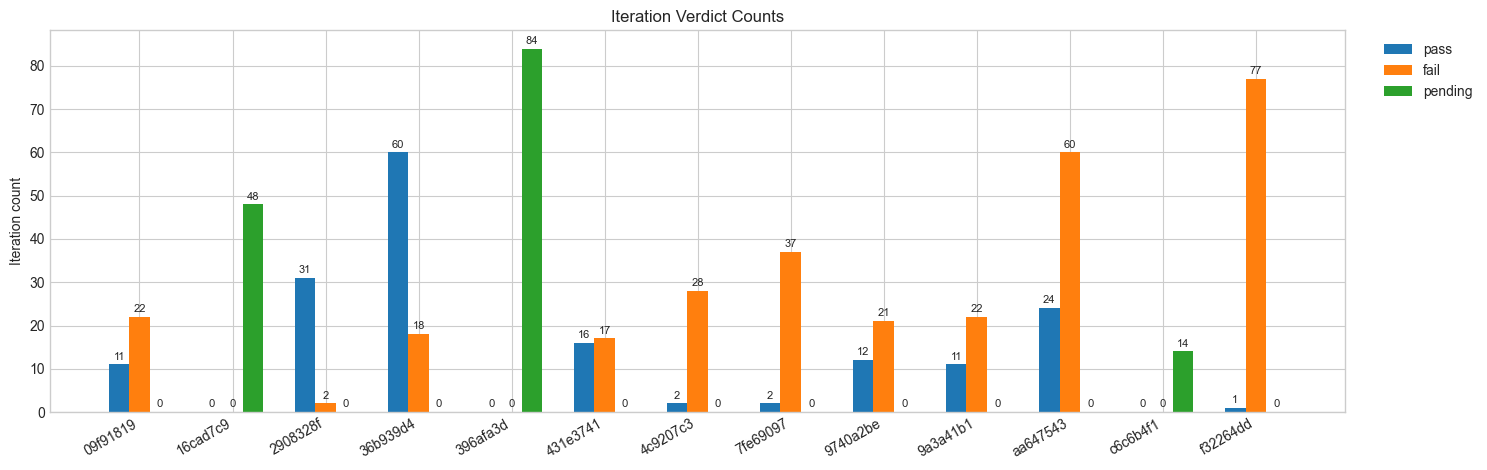

In [12]:
if iterations_df.empty:
    print('No iteration metrics available.')
else:
    verdict_counts = iterations_df.groupby(['run_id', 'final_verdict']).size().unstack(fill_value=0).reset_index()
    verdict_counts['label'] = verdict_counts['run_id']
    for col in ['pass', 'fail', 'pending']:
        if col not in verdict_counts:
            verdict_counts[col] = 0
    display(verdict_counts)

    grouped_bar(
        verdict_counts,
        'label',
        ['pass', 'fail', 'pending'],
        'Iteration Verdict Counts',
        'Iteration count',
        '07_iteration_verdict_counts.png'
    )

## 12. Export DataFrames

In [13]:
exports = {
    'runs_df.csv': runs_df,
    'tests_df.csv': tests_df,
    'iterations_df.csv': iterations_df,
    'type_df.csv': type_df,
    'severity_df.csv': severity_df,
}

for filename, df in exports.items():
    path = GRAPH_DIR / filename
    df.to_csv(path, index=False)
    print('Saved:', path)

Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\runs_df.csv
Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\tests_df.csv
Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\iterations_df.csv
Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\type_df.csv
Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\severity_df.csv
